# Baseline

# Set up Environment and load dataset

In [1]:
SPLIT = "test"         
SAMPLE_PER_GROUP = 300 
MAX_CHARS = 800       
SEED = 42

SAVE_DIR = "experiments/baseline_results"
FIG_DIR  = "figures/decay_curves"

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
###Set project root + import src（Code）
ROOT = Path("..").resolve()
sys.path.append(str(ROOT))

from src.data.load_data import list_datasets, load_processed_iteration

In [4]:
datasets = list_datasets(ROOT)
datasets

['cmv', 'eli5', 'sci_gen', 'tldr', 'wp', 'xsum', 'yelp']

In [5]:
def load_iter(iter_dir: str) -> pd.DataFrame:
    df = pd.concat(
        [load_processed_iteration(ROOT, iter_dir, ds) for ds in datasets],
        ignore_index=True
    )
    if SPLIT is not None and "split" in df.columns:
        df = df[df["split"] == SPLIT].copy()
    return df

t0 = load_iter("t0_human")
t1 = load_iter("t1_paraphrased")
t2 = load_iter("t2_paraphrased")
t3 = load_iter("t3_paraphrased")

len(t0), len(t1), len(t2), len(t3)

(3020, 134093, 133901, 132676)

### Build doc_id + pairs (T0 vs Tn)

In [6]:
def ensure_doc_id(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "doc_id" not in df.columns:
        df["doc_id"] = df["dataset"].astype(str) + "|" + df["key"].astype(str)
    return df

t0 = ensure_doc_id(t0)
t1 = ensure_doc_id(t1)
t2 = ensure_doc_id(t2)
t3 = ensure_doc_id(t3)

t0_base = (
    t0.rename(columns={"text": "text_t0"})[["doc_id", "dataset", "key", "text_t0"]]
      .drop_duplicates("doc_id")   # 关键：避免merge重复
)

def make_pairs(tn: pd.DataFrame, iteration: str) -> pd.DataFrame:
    tn = tn.copy()
    tn["iteration"] = iteration
    tn = tn.rename(columns={"text": "text_tn"})
    tn = tn[["doc_id", "dataset", "key", "paraphraser", "iteration", "text_tn"]]
    return tn.merge(t0_base, on=["doc_id", "dataset", "key"], how="inner")

pairs = pd.concat([make_pairs(t1, "t1"), make_pairs(t2, "t2"), make_pairs(t3, "t3")],
                  ignore_index=True)

pairs.shape

(400670, 7)

In [7]:
###Speed controls (text trim + empty filter)（Code）
pairs_run = pairs.copy()

pairs_run["text_t0"] = pairs_run["text_t0"].astype(str).str.slice(0, MAX_CHARS)
pairs_run["text_tn"] = pairs_run["text_tn"].astype(str).str.slice(0, MAX_CHARS)

pairs_run = pairs_run[
    (pairs_run["text_t0"].str.strip() != "") &
    (pairs_run["text_tn"].str.strip() != "")
].reset_index(drop=True)

if SAMPLE_PER_GROUP is not None:
    pairs_run = (
        pairs_run.groupby(["dataset","paraphraser","iteration"], group_keys=False, sort=False)
                 .apply(lambda g: g.sample(n=min(len(g), SAMPLE_PER_GROUP), random_state=SEED))
                 .reset_index(drop=True)
    )

pairs_run.shape

C:\Users\johns\AppData\Local\Temp\ipykernel_15752\1525097506.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), SAMPLE_PER_GROUP), random_state=SEED))


(25200, 7)

### Sanity Check and ROUGE-L(Lexical)

In [8]:
pairs_run.groupby(["paraphraser","iteration"]).size().unstack()
### ROUGE-L similarity
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1","rougeL"], use_stemmer=True)
tmp = scorer.score("a b c", "a b d")
tmp.keys(), tmp["rougeL"].fmeasure

from src.similarity.bleu_rouge import compute_rougel_pairs
rouge_res = compute_rougel_pairs(pairs_run)
rouge_res

,paraphraser,iteration,metric,mean,std,n
0,chatgpt,t1,rougeL_f,0.273755,0.119072,2100
6,chatgpt,t2,rougeL_f,0.258181,0.109603,2100
10,chatgpt,t3,rougeL_f,0.240096,0.098994,2100
3,dipper,t1,rougeL_f,0.233913,0.148689,2100
7,dipper,t2,rougeL_f,0.208456,0.130078,2100
11,dipper,t3,rougeL_f,0.192266,0.121029,2100
1,palm,t1,rougeL_f,0.318518,0.164541,2100
5,palm,t2,rougeL_f,0.282306,0.145399,2100
9,palm,t3,rougeL_f,0.266287,0.136803,2100
2,pegasus,t1,rougeL_f,0.376558,0.195542,2100


In [9]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### BERTScore(Semantic) on GPU

In [10]:
from src.similarity.bertscore import compute_bertscore_pairs
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
bert_res = compute_bertscore_pairs(
    pairs_run,
    model_type="distilroberta-base",
    batch_size=64,
    device=device
)
bert_res

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


  0%|          | 0/437 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/394 [00:00<?, ?it/s]

done in 73.83 seconds, 341.30 sentences/sec


,paraphraser,iteration,metric,mean,std,n
0,chatgpt,t1,bertscore_f1,0.334014,0.157304,2100
1,chatgpt,t2,bertscore_f1,0.313974,0.154066,2100
2,chatgpt,t3,bertscore_f1,0.297381,0.147368,2100
3,dipper,t1,bertscore_f1,0.215824,0.225388,2100
4,dipper,t2,bertscore_f1,0.182315,0.214058,2100
5,dipper,t3,bertscore_f1,0.166621,0.208945,2100
6,palm,t1,bertscore_f1,0.357567,0.189671,2100
7,palm,t2,bertscore_f1,0.322266,0.180501,2100
8,palm,t3,bertscore_f1,0.308675,0.176517,2100
9,pegasus,t1,bertscore_f1,0.399294,0.220879,2100


### Combine baseline table

In [11]:
baseline = pd.concat([rouge_res, bert_res], ignore_index=True)
baseline

,paraphraser,iteration,metric,mean,std,n
0,chatgpt,t1,rougeL_f,0.273755,0.119072,2100
1,chatgpt,t2,rougeL_f,0.258181,0.109603,2100
2,chatgpt,t3,rougeL_f,0.240096,0.098994,2100
3,dipper,t1,rougeL_f,0.233913,0.148689,2100
4,dipper,t2,rougeL_f,0.208456,0.130078,2100
5,dipper,t3,rougeL_f,0.192266,0.121029,2100
6,palm,t1,rougeL_f,0.318518,0.164541,2100
7,palm,t2,rougeL_f,0.282306,0.145399,2100
8,palm,t3,rougeL_f,0.266287,0.136803,2100
9,pegasus,t1,rougeL_f,0.376558,0.195542,2100


### Update 1 required table (T0 vs T1/T2/T3 across 4 paraphrasers)

In [12]:
table = baseline.pivot_table(
    index=["paraphraser","iteration"],
    columns="metric",
    values="mean"
).reset_index()

table

metric,paraphraser,iteration,bertscore_f1,rougeL_f
0,chatgpt,t1,0.334014,0.273755
1,chatgpt,t2,0.313974,0.258181
2,chatgpt,t3,0.297381,0.240096
3,dipper,t1,0.215824,0.233913
4,dipper,t2,0.182315,0.208456
5,dipper,t3,0.166621,0.192266
6,palm,t1,0.357567,0.318518
7,palm,t2,0.322266,0.282306
8,palm,t3,0.308675,0.266287
9,pegasus,t1,0.399294,0.376558


### Decay plot: Style vs Content

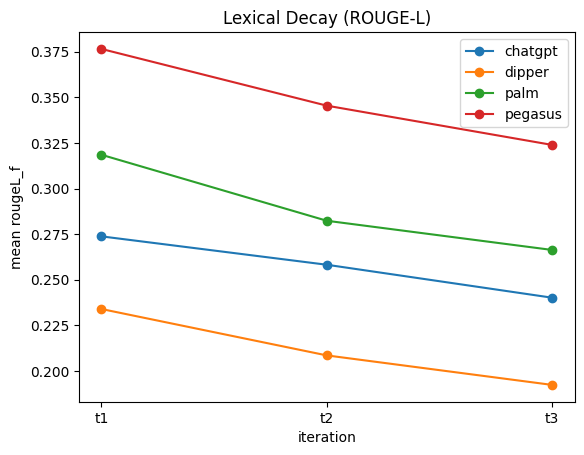

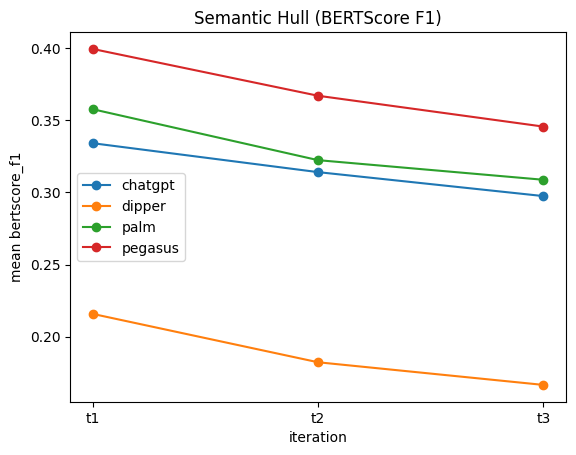

In [13]:
import matplotlib.pyplot as plt

def plot_decay(baseline_df, metric, title):
    d = baseline_df[baseline_df["metric"] == metric].copy()
    order = ["t1","t2","t3"]
    d["iteration"] = pd.Categorical(d["iteration"], order, ordered=True)

    plt.figure()
    for p, g in d.groupby("paraphraser"):
        g = g.sort_values("iteration")
        plt.plot(g["iteration"], g["mean"], marker="o", label=p)
    plt.title(title)
    plt.xlabel("iteration")
    plt.ylabel(f"mean {metric}")
    plt.legend()
    plt.show()

plot_decay(baseline, "rougeL_f", "Lexical Decay (ROUGE-L)")
plot_decay(baseline, "bertscore_f1", "Semantic Hull (BERTScore F1)")

### Save outputs(table + figures)

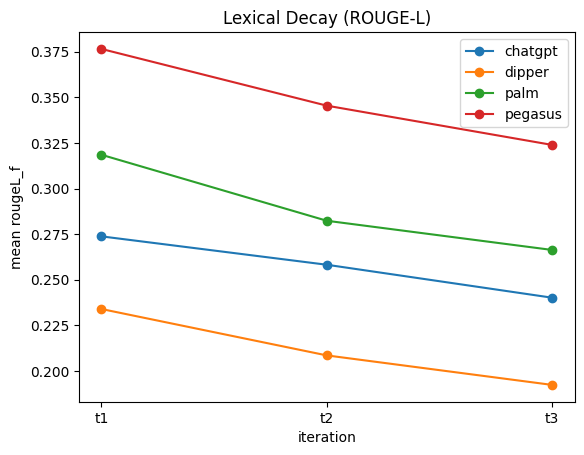

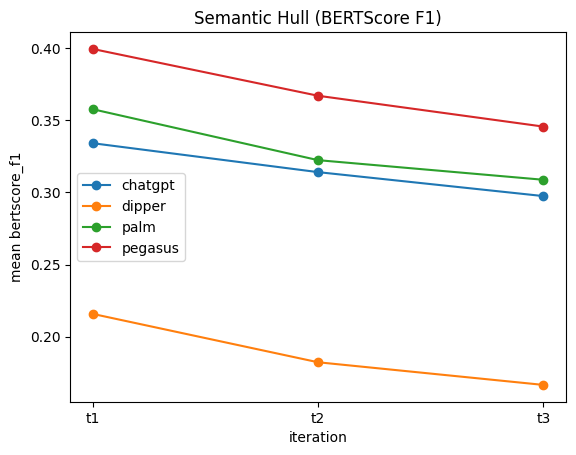

In [14]:
from pathlib import Path

(Path(ROOT / SAVE_DIR)).mkdir(parents=True, exist_ok=True)
(Path(ROOT / FIG_DIR)).mkdir(parents=True, exist_ok=True)

baseline.to_csv(ROOT / SAVE_DIR / f"baseline_metrics_{SPLIT}_sample{SAMPLE_PER_GROUP}.csv", index=False)
table.to_csv(ROOT / SAVE_DIR / f"baseline_table_{SPLIT}_sample{SAMPLE_PER_GROUP}.csv", index=False)

# 重新画一次并保存
def save_decay(metric, title, fname):
    d = baseline[baseline["metric"] == metric].copy()
    order = ["t1","t2","t3"]
    d["iteration"] = pd.Categorical(d["iteration"], order, ordered=True)

    plt.figure()
    for p, g in d.groupby("paraphraser"):
        g = g.sort_values("iteration")
        plt.plot(g["iteration"], g["mean"], marker="o", label=p)
    plt.title(title)
    plt.xlabel("iteration")
    plt.ylabel(f"mean {metric}")
    plt.legend()
    plt.savefig(ROOT / FIG_DIR / fname, dpi=200, bbox_inches="tight")
    plt.show()

save_decay("rougeL_f", "Lexical Decay (ROUGE-L)", f"decay_rougeL_{SPLIT}_sample{SAMPLE_PER_GROUP}.png")
save_decay("bertscore_f1", "Semantic Hull (BERTScore F1)", f"decay_bertscore_{SPLIT}_sample{SAMPLE_PER_GROUP}.png")


In [16]:
### ROUGE vs BertScore Table
def pivot_metric(df, metric_name):
    tmp = df[df["metric"] == metric_name].copy()
    return tmp.pivot(index="paraphraser", columns="iteration", values="mean").loc[:, ["t1","t2","t3"]]

rouge_tbl = pivot_metric(baseline, "rougeL_f") if (baseline["metric"]=="rougeL_f").any() else pivot_metric(baseline, "rouge1_f")
bert_tbl  = pivot_metric(baseline, "bertscore_f1")
from pathlib import Path

ROOT = Path("..").resolve()
SAVE_DIR = ROOT / "experiments" / "baseline_results"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
rouge_tbl.to_csv(SAVE_DIR / "rouge_table.csv")
bert_tbl.to_csv(SAVE_DIR / "bertscore_table.csv")

rouge_tbl, bert_tbl

(iteration          t1        t2        t3
 paraphraser                              
 chatgpt      0.273755  0.258181  0.240096
 dipper       0.233913  0.208456  0.192266
 palm         0.318518  0.282306  0.266287
 pegasus      0.376558  0.345437  0.323894,
 iteration          t1        t2        t3
 paraphraser                              
 chatgpt      0.334014  0.313974  0.297381
 dipper       0.215824  0.182315  0.166621
 palm         0.357567  0.322266  0.308675
 pegasus      0.399294  0.366863  0.345494)

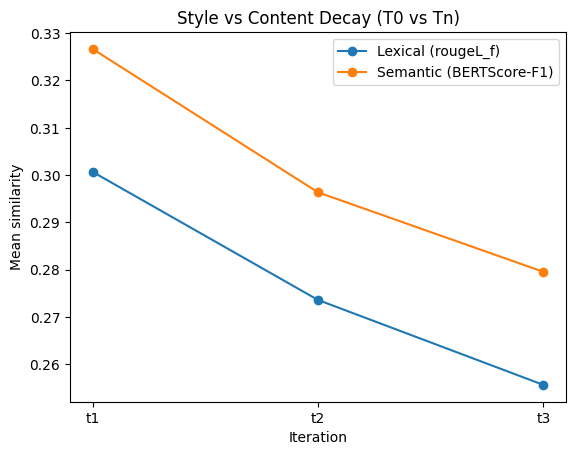

In [17]:
import matplotlib.pyplot as plt

FIG_DIR = ROOT / "figures" / "decay_curves"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 找 rouge metric 名
rouge_metric = "rougeL_f" if (baseline["metric"]=="rougeL_f").any() else "rouge1_f"

lex = baseline[baseline["metric"] == rouge_metric].groupby("iteration")["mean"].mean().reindex(["t1","t2","t3"])
sem = baseline[baseline["metric"] == "bertscore_f1"].groupby("iteration")["mean"].mean().reindex(["t1","t2","t3"])

plt.figure()
plt.plot(lex.index, lex.values, marker="o", label=f"Lexical ({rouge_metric})")
plt.plot(sem.index, sem.values, marker="o", label="Semantic (BERTScore-F1)")
plt.title("Style vs Content Decay (T0 vs Tn)")
plt.xlabel("Iteration")
plt.ylabel("Mean similarity")
plt.legend()
plt.savefig(FIG_DIR / "style_vs_content_decay.png", dpi=200, bbox_inches="tight")
plt.show()

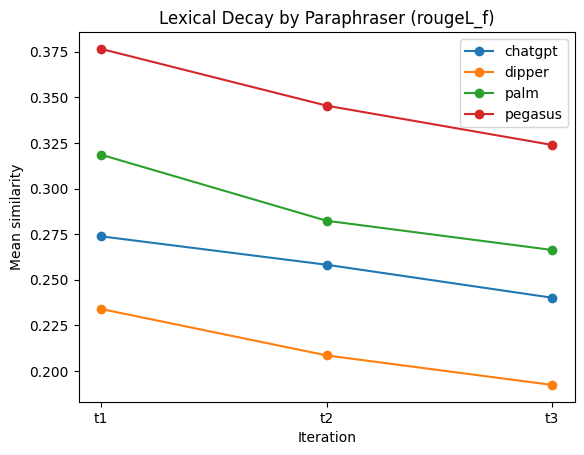

In [18]:
plt.figure()
for p in ["chatgpt","dipper","palm","pegasus"]:
    tmp = baseline[(baseline["metric"]==rouge_metric) & (baseline["paraphraser"]==p)].set_index("iteration")["mean"].reindex(["t1","t2","t3"])
    plt.plot(tmp.index, tmp.values, marker="o", label=p)

plt.title(f"Lexical Decay by Paraphraser ({rouge_metric})")
plt.xlabel("Iteration")
plt.ylabel("Mean similarity")
plt.legend()
plt.savefig(FIG_DIR / "lexical_decay_by_paraphraser.png", dpi=200, bbox_inches="tight")
plt.show()

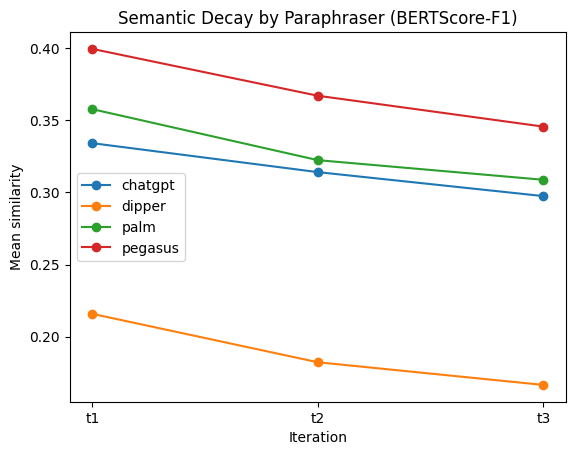

In [19]:
plt.figure()
for p in ["chatgpt","dipper","palm","pegasus"]:
    tmp = baseline[(baseline["metric"]=="bertscore_f1") & (baseline["paraphraser"]==p)].set_index("iteration")["mean"].reindex(["t1","t2","t3"])
    plt.plot(tmp.index, tmp.values, marker="o", label=p)

plt.title("Semantic Decay by Paraphraser (BERTScore-F1)")
plt.xlabel("Iteration")
plt.ylabel("Mean similarity")
plt.legend()
plt.savefig(FIG_DIR / "semantic_decay_by_paraphraser.png", dpi=200, bbox_inches="tight")
plt.show()